# Asset Price Modeling Walkthrough

This notebook follows `SPECS/units/asset_price_modeling/task.md` and the lecture notes in `Asset_Price_Modeling/Asset_Price_Modeling.md`.

Covered topics:
1. Symmetric random walk
2. Brownian motion
3. Geometric Brownian motion (GBM)
4. Drift and volatility estimation
5. Jump diffusion


In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from quant_edu.asset_price_modeling import (
    estimate_drift_and_volatility,
    fetch_close_prices,
    realized_volatility,
    simulate_brownian_motion,
    simulate_geometric_brownian_motion,
    simulate_jump_diffusion,
    simulate_symmetric_random_walk,
)

plt.style.use("seaborn-v0_8")

## 1) Symmetric Random Walk

Model statement:

$$
X_j = \begin{cases}
+1, & \text{with probability } \tfrac{1}{2} \
-1, & \text{with probability } \tfrac{1}{2}
\end{cases}
$$

$$
M_k = \sum_{j=1}^{k} X_j, \qquad M_0 = 0.
$$

Interpretation: each step moves one unit up or down.

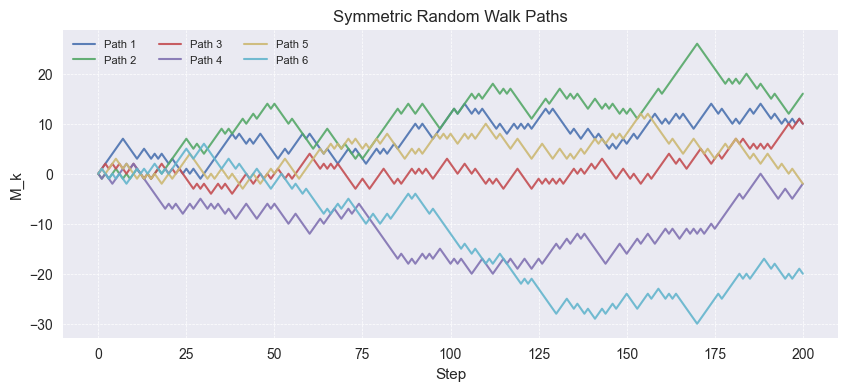

In [2]:
n_steps = 200
n_paths = 6
rw_paths = simulate_symmetric_random_walk(n_steps=n_steps, n_paths=n_paths, seed=7)

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(n_paths):
    ax.可是plot(rw_paths[i], lw=1.5, alpha=0.9, label=f"Path {i + 1}")
ax.set_title("Symmetric Random Walk Paths")
ax.set_xlabel("Step")
ax.set_ylabel("M_k")
ax.grid(True, ls="--", lw=0.5)
ax.legend(ncol=3, fontsize=8)
plt.show()


## 2) Brownian Motion

Increment rule for simulation:

$$
W(t_{i+1}) - W(t_i) \sim \mathcal{N}(0, t_{i+1}-t_i).
$$

With a uniform grid:

$$
\Delta t = \frac{\text{horizon}}{n_{\text{steps}}},
$$

and increments are sampled as $\mathcal{N}(0, \Delta t)$.


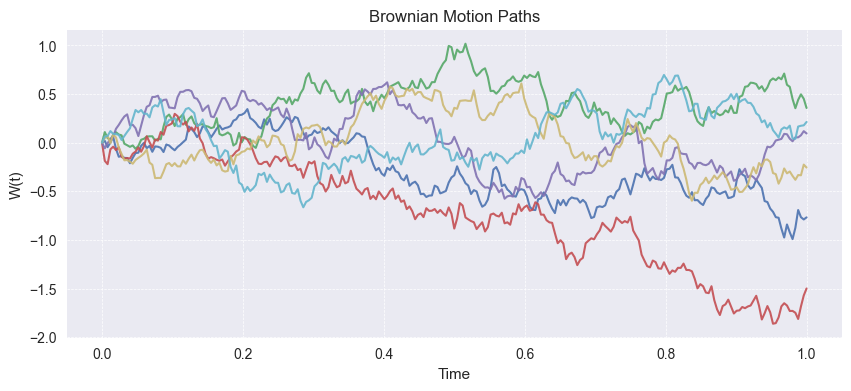

In [3]:
n_steps = 252
horizon = 1.0
n_paths = 6
bm_paths = simulate_brownian_motion(
    n_steps=n_steps, horizon=horizon, n_paths=n_paths, seed=42
)
t = np.linspace(0.0, horizon, n_steps + 1)

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(n_paths):
    ax.plot(t, bm_paths[i], lw=1.5, alpha=0.9)
ax.set_title("Brownian Motion Paths")
ax.set_xlabel("Time")
ax.set_ylabel("W(t)")
ax.grid(True, ls="--", lw=0.5)
plt.show()


## 3) Geometric Brownian Motion (GBM)

Model statement:

$$
\frac{dS(t)}{S(t)} = \alpha \, dt + \sigma \, dW(t).
$$

Closed-form solution:

$$
S(t) = S(0) \exp\left( \sigma W(t) + \left(\alpha - \frac{1}{2}\sigma^2\right)t \right).
$$

The simulator uses a discrete log-return version of this formula.

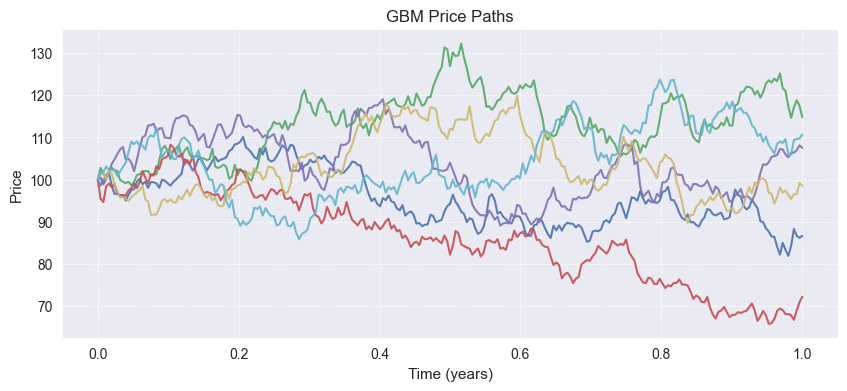

In [4]:
n_steps = 252
horizon = 1.0
n_paths = 6
s0 = 100.0
drift = 0.08
volatility = 0.25

gbm_paths = simulate_geometric_brownian_motion(
    n_steps=n_steps,
    horizon=horizon,
    n_paths=n_paths,
    s0=s0,
    drift=drift,
    volatility=volatility,
    seed=42,
)
t = np.linspace(0.0, horizon, n_steps + 1)

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(n_paths):
    ax.plot(t, gbm_paths[i], lw=1.5, alpha=0.9)
ax.set_title("GBM Price Paths")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Price")
ax.grid(True, ls="--", lw=0.5)
plt.show()


## 4) Drift and Volatility Estimation

For log return $r_j = \log\left(\frac{S_{t_{j+1}}}{S_{t_j}}\right)$ under GBM:

$$
\mathbb{E}[r_j] = \left(\alpha - \frac{1}{2}\sigma^2\right)\Delta t, \qquad
\mathrm{Var}(r_j) = \sigma^2 \Delta t.
$$

Realized volatility approximation from the lecture notes:

$$
\sigma^2 \approx \frac{1}{T_2 - T_1}\sum_{j=0}^{m-1}\left(\log\frac{S(t_{j+1})}{S(t_j)}\right)^2.
$$

For estimation, this notebook uses real AAPL daily closes from the fixture dataset.

In [5]:
symbol = "AAPL"
period = "1y"
dt = 1 / 252

prices = fetch_close_prices(symbol, period=period)

estimate = estimate_drift_and_volatility(prices=prices, dt=dt)
rv = realized_volatility(prices=prices, dt=dt)

print(f"Symbol: {symbol}  |  {prices.size} trading days loaded")
print("Estimated drift:     ", round(estimate.drift, 4))
print("Estimated volatility:", round(estimate.volatility, 4))
print("Realized volatility: ", round(rv, 4))

## 5) Jump Diffusion

Lecture idea: combine GBM diffusion and Poisson jumps.

A practical simulator form in log space is:

$$
\Delta \log S \approx \left(\alpha - \frac{1}{2}\sigma^2 - \lambda \kappa\right)\Delta t
 + \sigma\sqrt{\Delta t}Z + \text{jump component},
$$

with jump counts per step drawn from

$$
N_{\Delta t} \sim \text{Poisson}(\lambda \Delta t).
$$


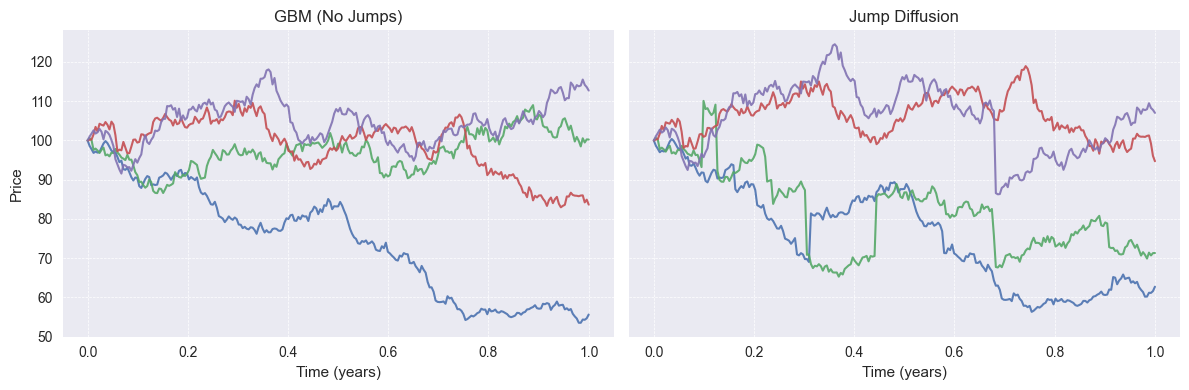

In [6]:
n_steps = 252
horizon = 1.0
t = np.linspace(0.0, horizon, n_steps + 1)

gbm_reference = simulate_geometric_brownian_motion(
    n_steps=n_steps,
    horizon=horizon,
    n_paths=4,
    s0=100.0,
    drift=0.08,
    volatility=0.2,
    seed=10,
)

jump_paths = simulate_jump_diffusion(
    n_steps=n_steps,
    horizon=horizon,
    n_paths=4,
    s0=100.0,
    drift=0.08,
    volatility=0.2,
    jump_intensity=6.0,
    jump_mean=-0.03,
    jump_std=0.1,
    seed=10,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for i in range(gbm_reference.shape[0]):
    axes[0].plot(t, gbm_reference[i], lw=1.5, alpha=0.9)
for i in range(jump_paths.shape[0]):
    axes[1].plot(t, jump_paths[i], lw=1.5, alpha=0.9)

axes[0].set_title("GBM (No Jumps)")
axes[1].set_title("Jump Diffusion")
for ax in axes:
    ax.set_xlabel("Time (years)")
    ax.grid(True, ls="--", lw=0.5)
axes[0].set_ylabel("Price")
plt.tight_layout()
plt.show()


## Notes

- Every stochastic API exposes `seed` for reproducibility.
- Time convention: `dt = horizon / n_steps`.
- The notebook uses public APIs from `quant_edu.asset_price_modeling`.